**SESSION 4**

**1. 
Load the Iris dataset using sklearn, apply PCA to reduce it to 2 principal components, 
and print the explained variance ratio for both components.**

In [104]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [3]:
iris = load_iris()
X = iris.data

In [5]:
print("Explained Variance Ratio:")
print("Principal Component 1:", pca.explained_variance_ratio_[0])
print("Principal Component 2:", pca.explained_variance_ratio_[1])

Explained Variance Ratio:
Principal Component 1: 0.9246187232017271
Principal Component 2: 0.053066483117067846


In [13]:
print("\nFirst 5 rows of transformed data:")
print(X_pca[:5])


First 5 rows of transformed data:
[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]
 [-2.74534286 -0.31829898]
 [-2.72871654  0.32675451]]


**2.
Plot the 2D projection of the Iris dataset after PCA transformation, using a different color
 for each species, similar to how Spotify visualizes genre clusters.<br><br><em><strong>
Hint:</strong> Use matplotlib's scatter() and color by target label.</em>**

In [19]:
import matplotlib.pyplot as plt

In [23]:
y = iris.target
target_names = iris.target_names

In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

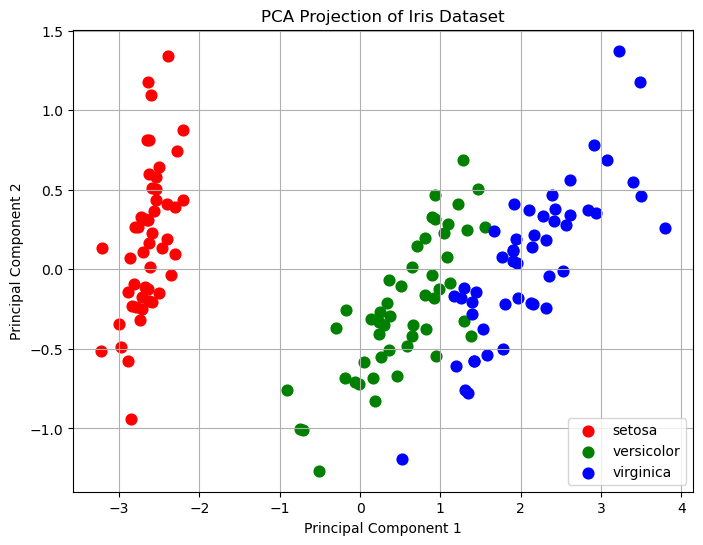

In [29]:
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for i, color, label in zip(range(3), colors, target_names):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        color=color,
        label=label,
        s=60
    )

plt.title("PCA Projection of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

**3. Given a dataset of Zomato restaurant ratings with 10 features, use PCA from sklearn to 
reduce the data to 3 components and visualize the cumulative explained variance as a line plot.**  

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [108]:
df = pd.read_csv("enhanced_zomato_dataset_clean.csv")
df.head()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,...,Is_Bestseller,Restaurant_Popularity,Avg_Rating_Restaurant,Avg_Price_Restaurant,Avg_Rating_Cuisine,Avg_Price_Cuisine,Avg_Rating_City,Avg_Price_City,Is_Highly_Rated,Is_Expensive
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NONE,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0


In [112]:
df.columns

Index(['Restaurant_Name', 'Dining_Rating', 'Delivery_Rating', 'Dining_Votes',
       'Delivery_Votes', 'Cuisine', 'Place_Name', 'City', 'Item_Name',
       'Best_Seller', 'Votes', 'Prices', 'Average_Rating', 'Total_Votes',
       'Price_per_Vote', 'Log_Price', 'Is_Bestseller', 'Restaurant_Popularity',
       'Avg_Rating_Restaurant', 'Avg_Price_Restaurant', 'Avg_Rating_Cuisine',
       'Avg_Price_Cuisine', 'Avg_Rating_City', 'Avg_Price_City',
       'Is_Highly_Rated', 'Is_Expensive'],
      dtype='object')

In [63]:
df["Is_Expensive"].unique()

array([0, 1], dtype=int64)

In [37]:
X = df.iloc[:, :10]

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ValueError: could not convert string to float: 'Aroma Cafe'

In [43]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

NameError: name 'X_scaled' is not defined

In [45]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Calculate cumulative explained variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()

Explained Variance Ratio:


AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

In [65]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, 4),
    cumulative_variance,
    marker='o',
    linestyle='-'
)

plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks([1, 2, 3])
plt.grid(True)
plt.show()

NameError: name 'cumulative_variance' is not defined

<Figure size 800x500 with 0 Axes>

**4.
Take the PCA-transformed Iris data (2 components) and run KMeans clustering wit  h
 3 clusters. Plot the clusters and centroids on the 2D PCA plo**  t.t.

In [69]:
from sklearn.cluster import KMeans

In [106]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_pca)

centroids = kmeans.cluster_centers_

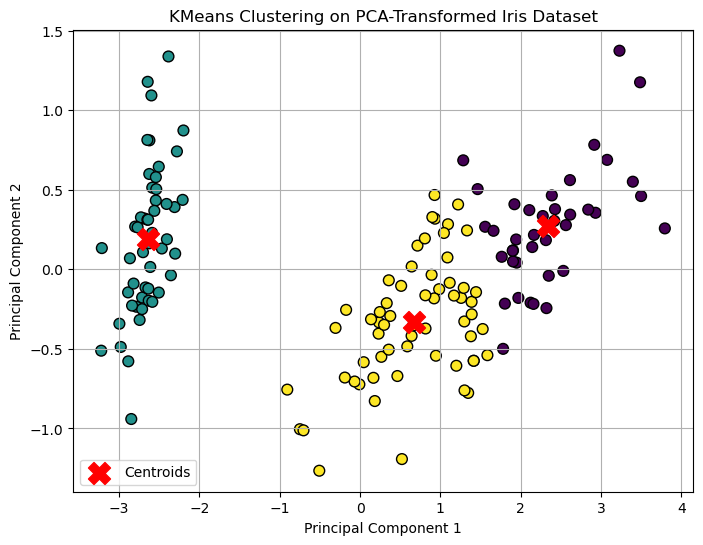

In [77]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis',
    s=60,
    edgecolor='k'
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("KMeans Clustering on PCA-Transformed Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

**5. Use the silhouette_score function from sklearn.metrics to evaluate the quality of your KMeans clusters on the  
PCA-reduced Iris data. Print the silhouette score and explain what it indicates about your clustering result in 2-3 lines.**  


In [81]:
from sklearn.metrics import silhouette_score

In [83]:
score = silhouette_score(X_pca, labels)

In [87]:
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.598


**The Silhouette Score measures how well-separated the clusters are. Its value ranges from -1 to 1, where a score closer to 1 indicates dense,  
well-separated clusters, while a score near 0 indicates overlapping clusters.  
A score of around 0.6 suggests that the KMeans clustering has produced reasonably well-defined clusters on the PCA-reduced Iris dataset.**    